In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [14]:
df = pd.read_csv("googleplaystore.csv", on_bad_lines='skip')
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13464 entries, 0 to 13463
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             13464 non-null  object 
 1   Category        13464 non-null  object 
 2   Rating          11432 non-null  float64
 3   Reviews         13464 non-null  object 
 4   Size            13464 non-null  object 
 5   Installs        13464 non-null  object 
 6   Type            13462 non-null  object 
 7   Price           13464 non-null  object 
 8   Content Rating  13462 non-null  object 
 9   Genres          13464 non-null  object 
 10  Last Updated    13464 non-null  object 
 11  Current Ver     13455 non-null  object 
 12  Android Ver     13460 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.3+ MB


App                  0
Category             0
Rating            2032
Reviews              0
Size                 0
Installs             0
Type                 2
Price                0
Content Rating       2
Genres               0
Last Updated         0
Current Ver          9
Android Ver          4
dtype: int64

In [15]:
#cleaning the columns: 
#'Installs'column
df['Installs'] = df['Installs'].astype(str).str.replace('+', '').str.replace(',', '')
df = df[df['Installs'] != 'Free']
df['Installs'] = pd.to_numeric(df['Installs'])

#'Price'column
df['Price'] = df['Price'].str.replace('$', '').astype(float)

#'Reviews'column
df['Reviews'] = pd.to_numeric(df['Reviews'])

In [16]:
#Task1

print("Missing Values per Column:")
print(df.isnull().sum())

print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

print("\nData Types:")
print(df.dtypes)

Missing Values per Column:
App                  0
Category             0
Rating            2032
Reviews              0
Size                 0
Installs             0
Type                 2
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          9
Android Ver          2
dtype: int64

Total Duplicate Rows: 3105

Data Types:
App                object
Category           object
Rating            float64
Reviews             int64
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


In [17]:
#Task2
# Strategy: Median Imputation
# Why: App ratings are usually skewed

median_val = df['Rating'].median()
df['Rating'] = df['Rating'].fillna(median_val)

print(f"Missing values in Rating after cleaning: {df['Rating'].isnull().sum()}")

Missing values in Rating after cleaning: 0


In [19]:
#Task3
Q1 = df['Reviews'].quantile(0.25)
Q3 = df['Reviews'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Reviews'] = df['Reviews'].clip(lower=lower_bound, upper=upper_bound)

print(f"Reviews are now between {lower_bound} and {upper_bound}")

Reviews are now between -62537.125 and 104295.875


In [21]:
#Task4
cols_to_scale = ['Rating', 'Reviews', 'Installs', 'Price']

#Min-Max Scaling
min_max = MinMaxScaler()
df_minmax = pd.DataFrame(min_max.fit_transform(df[cols_to_scale]), columns=cols_to_scale)

#Z-score(standardization)
standard = StandardScaler()
df_zscore = pd.DataFrame(standard.fit_transform(df[cols_to_scale]), columns=cols_to_scale)

print("Standardized Data (Z-score) Head:")
print(df_zscore.head())

Standardized Data (Z-score) Head:
     Rating   Reviews  Installs     Price
0 -0.197131 -0.654073 -0.168598 -0.063574
1 -0.605466 -0.634157 -0.162241 -0.063574
2  1.027876  1.498982 -0.103856 -0.063574
3  0.619540  1.912725  0.479984 -0.063574
4  0.211205 -0.634157 -0.167430 -0.063574


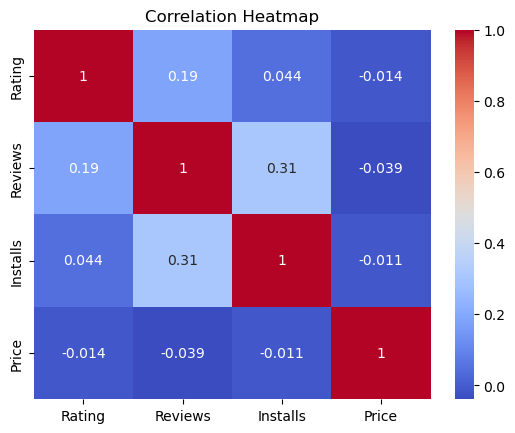


PCA Explained Variance Ratio: [0.3464512  0.24935616]


In [22]:
#Task5
correlation_matrix = df[cols_to_scale].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(df_zscore)

df_pca = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
print("\nPCA Explained Variance Ratio:", pca.explained_variance_ratio_)